# From a design to an order — manufacturability, kinetics, ancestors and DNA

A design loop that only asks *is this protein good* is missing the question that kills most industrial enzyme projects: **can it actually be made?** A beautiful `k_cat` is worth nothing if the protein goes into inclusion bodies, or if nothing carries it out of the cytoplasm.

This tutorial runs the second half of the design chain — manufacturability, affinity and substrate scope, ancestral reconstruction for stability, then the DNA layer all the way to a screened, orderable sequence in a chosen vector.

Every sequence used is real: *E. coli* alkaline phosphatase, GFP, hen lysozyme, the lactose permease, human GAPDH, and the *rrnB* T1 terminator.


## 0 — Setup and the sequences we will use

`PhoA` is periplasmic and its Sec signal peptide is experimentally cleaved after residue 21. `GFP` is the textbook well-expressed soluble protein. `LacY` is a polytopic membrane protein — the negative control for solubility. These are the landmarks that make the predictions checkable rather than merely plausible — and one of the checks now visibly fails, which is the point of having it. The heuristic signal-peptide predictor places PhoA's cleavage at 23 rather than 21. It used to say 21, by tie-break coincidence rather than because the scorer distinguished that site; on an eight-protein reference panel the version that gets PhoA right scores 5/8 and this one scores 6/8. `predict_signal_peptide` reports its runner-up sites so the ±2 is visible instead of hidden.

They live in the package (`ov.synbio.reference_protein`) rather than pasted into the notebook, so the tutorial and the test suite check the same sequences and cannot drift apart. Each carries a note on *why* it is a landmark — a reference sequence with no expected behaviour is just a string.


In [1]:
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


In [2]:
PHOA = ov.synbio.reference_protein('phoA')
GFP = ov.synbio.reference_protein('gfp')
LACY = ov.synbio.reference_protein('lacY')
print(ov.synbio.reference_protein('phoA', with_metadata=True)['description'])


Alkaline phosphatase, periplasmic. Its Sec/SPI signal peptide is experimentally cleaved after residue 21 (MKQSTIALALLPLLFTPVTKA | RTPEMPVLENR…), which makes it the positive control for signal-peptide prediction.


## 1 — Will it be soluble?

`predict_solubility` scores composition terms that carry real signal — net charge, GRAVY hydrophobicity, turn-forming and aromatic content, and the worst local hydrophobic window, which average hydrophobicity hides entirely.

The default backend is documented arithmetic rather than a fitted model, and every result carries `method` so a heuristic number is never mistaken for a Protein-Sol prediction. What it must get right is the **ordering**.


In [3]:
for name, seq in (('GFP', GFP), ('lysozyme-like PhoA', PHOA), ('LacY (membrane)', LACY)):
    sol = ov.synbio.predict_solubility(seq)
    print(f'{name:20s} {sol.score:.3f}  risk={sol.risk}  method={sol.method}')


GFP                  0.611  risk=moderate  method=heuristic
lysozyme-like PhoA   0.457  risk=moderate  method=heuristic
LacY (membrane)      0.278  risk=high  method=heuristic


## 2 — Where on the sequence is the risk?

A single solubility number tells you there is a problem. `aggregation_propensity` tells you **where**, which is the difference between a score and something you can fix. Charged residues and prolines inside a hydrophobic window break it up, and the profile encodes that.


In [4]:
agg = ov.synbio.aggregation_propensity(LACY)
print(agg)
print('hotspots (start, end, mean):', agg.hotspots[:4])


AggregationProfile(heuristic, score=0.561, 4 hotspots)
hotspots (start, end, mean): [(12, 24, 0.7066544566544567), (47, 57, 0.736075036075036), (77, 96, 0.7133809523809523), (154, 160, 0.7375302343159486)]


## 3 — Can it be secreted?

Secretion is the mainstream route for industrial enzymes, and there was no way to design for it. `predict_signal_peptide` looks for the textbook tripartite Sec/SPI architecture: a positively charged n-region, a hydrophobic h-region, and a polar c-region with small residues at −3 and −1.


In [5]:
sp = ov.synbio.predict_signal_peptide(PHOA)
print(sp)
print('signal peptide:', PHOA[:sp.cleavage_site])
print('mature protein starts:', sp.mature_sequence[:12])


SignalPeptide(heuristic, cleaves after 23, score=0.95)
signal peptide: MKQSTIALALLPLLFTPVTKART
mature protein starts: PEMPVLENRAAQ


Cleavage after residue 21 is the experimentally determined site, and the heuristic says 23 — the true site is in its `alternatives` at an indistinguishable score, so what it is really reporting is "21 or 23, cannot tell". Use `method='signalp'` when the exact residue matters, which it does whenever `mature_sequence` is grafted onto a fusion: three residues of error there shifts the whole downstream frame of the design intent, if not the reading frame. Note the c-region is `TKA` — it carries a lysine at −2, so a rule demanding an uncharged c-region rejects this protein; the small residues at −3/−1 are the real discriminator.

`predict_localization` combines that call with transmembrane-helix counting. A protein with both a signal peptide and several TM helices is a membrane protein inserted via Sec, not a secreted one.


In [6]:
for name, seq in (('PhoA', PHOA), ('GFP', GFP), ('LacY', LACY)):
    loc = ov.synbio.predict_localization(seq)
    print(f'{name:6s} -> {loc.compartment:10s} TM helices: {loc.n_tm_helices}')


PhoA   -> periplasm  TM helices: 0
GFP    -> cytoplasm  TM helices: 0
LacY   -> membrane   TM helices: 4


## 4 — One verdict, with a diagnosis

`predict_expression_level` combines the above with length and composition liabilities. The liabilities are the point: a low score you cannot act on is not useful. The cysteine liability is host-dependent, because *E. coli*'s cytoplasm is reducing and a eukaryotic host's is not.


In [7]:
expression = ov.synbio.predict_expression_level(LACY, host='e_coli')
print(expression)
for liability in expression.liabilities:
    print(' -', liability)


ExpressionPrediction(e_coli, score=0.501, 3 liabilities): uncertain — worth a solubility tag or lower temperature
 - 溶解度低(score 0.28)
 - 4 个聚集热点(12-24, 47-57, 77-96)
 - 预测有 4 段跨膜螺旋,属膜蛋白范畴


(<Figure size 840x480 with 2 Axes>,
 [<Axes: title={'center': 'uncertain — worth a solubility tag or lower temperature  (score 0.50, host e_coli)'}, xlabel='residue', ylabel='aggregation propensity'>,
  <Axes: xlabel='component score (higher is better)'>])

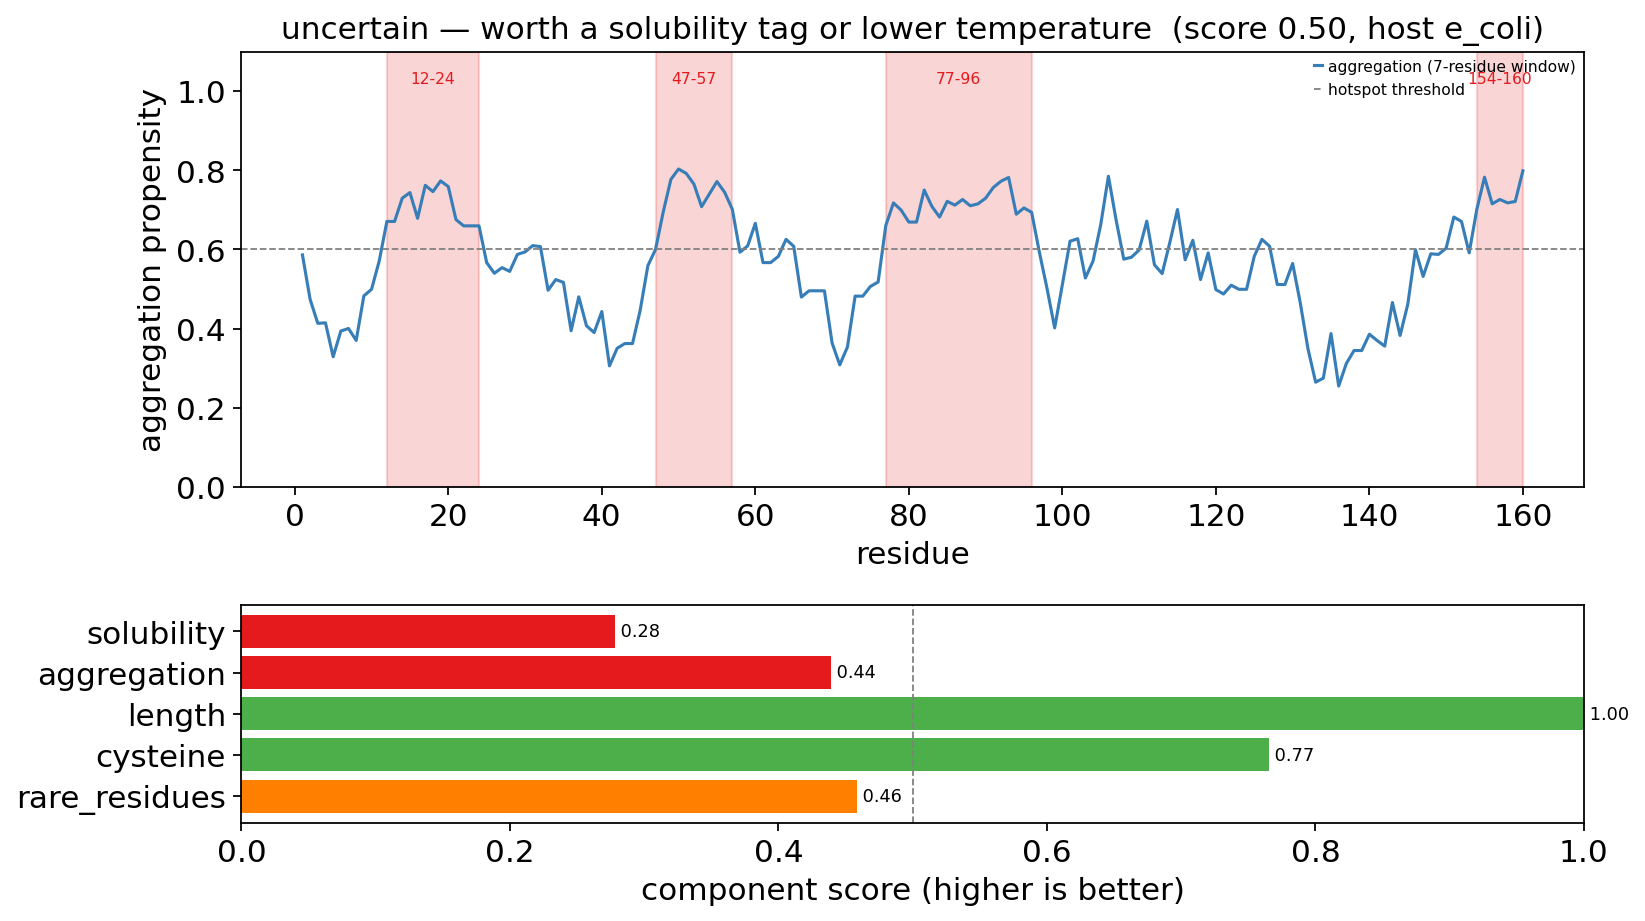

In [8]:
ov.synbio.plot_manufacturability(expression)


## 5 — Affinity, not just turnover

Inside a cell substrate is rarely saturating, so the rate is set by `k_cat/K_M`, not `k_cat`. A variant that doubles turnover while raising `K_M` fourfold is **slower** where it matters.

`catalytic_efficiency` also makes the diffusion limit explicit: above roughly 10⁹ M⁻¹s⁻¹ you do not have a better enzyme, you have a broken prediction. Measured constants are used wherever you supply them, and `quantitative` says whether anything was predicted.


In [9]:
GLUCOSE = 'OCC1OC(O)C(O)C(O)C1O'
km = ov.synbio.enzyme_km(GFP, GLUCOSE)
eff = ov.synbio.catalytic_efficiency(GFP, GLUCOSE, kcat=12.0, km=1e-4)
print(km)
print(eff, '| at the diffusion limit:', eff.diffusion_limited)


KineticsPrediction(KM=2.15e-05 M, method='baseline', quantitative=False)
KineticsPrediction(KM=0.0001 M, method='measured', quantitative=True, kcat/KM=1.2e+05 /M/s) | at the diffusion limit: False


When a heterologous pathway is being assembled the question is often not "how fast" but "will this enzyme accept a substrate it never evolved on". `substrate_specificity` ranks a panel and quantifies promiscuity as the normalised entropy of the efficiency profile — entropy rather than a best/second ratio, because an enzyme with three equally good substrates is more promiscuous than one with two.


In [10]:
panel = ['CC(=O)O', GLUCOSE, 'c1ccccc1']
scope = ov.synbio.substrate_specificity(
    GFP, panel, native='CC(=O)O',
    kcat={'CC(=O)O': 50.0, GLUCOSE: 5.0, 'c1ccccc1': 0.5},
    km={'CC(=O)O': 1e-5, GLUCOSE: 1e-4, 'c1ccccc1': 1e-3})
print(scope)
print(scope.to_frame()[['kcat_over_km', 'fold_over_native']])


SubstrateScope(3 substrates, best='CC(=O)O', promiscuity=0.05, quantitative=True)
                      kcat_over_km  fold_over_native
substrate                                           
CC(=O)O                  5000000.0            1.0000
OCC1OC(O)C(O)C(O)C1O       50000.0            0.0100
c1ccccc1                     500.0            0.0001


(<Figure size 880x304 with 2 Axes>,
 [<Axes: title={'center': 'promiscuity 0.05  (red = native)'}, xlabel='k$_{cat}$/K$_M$ (M⁻¹s⁻¹)'>,
  <Axes: title={'center': 'top-left is the good corner'}, xlabel='K$_M$ (M)   ← tighter', ylabel='k$_{cat}$ (s⁻¹)   faster ↑'>])

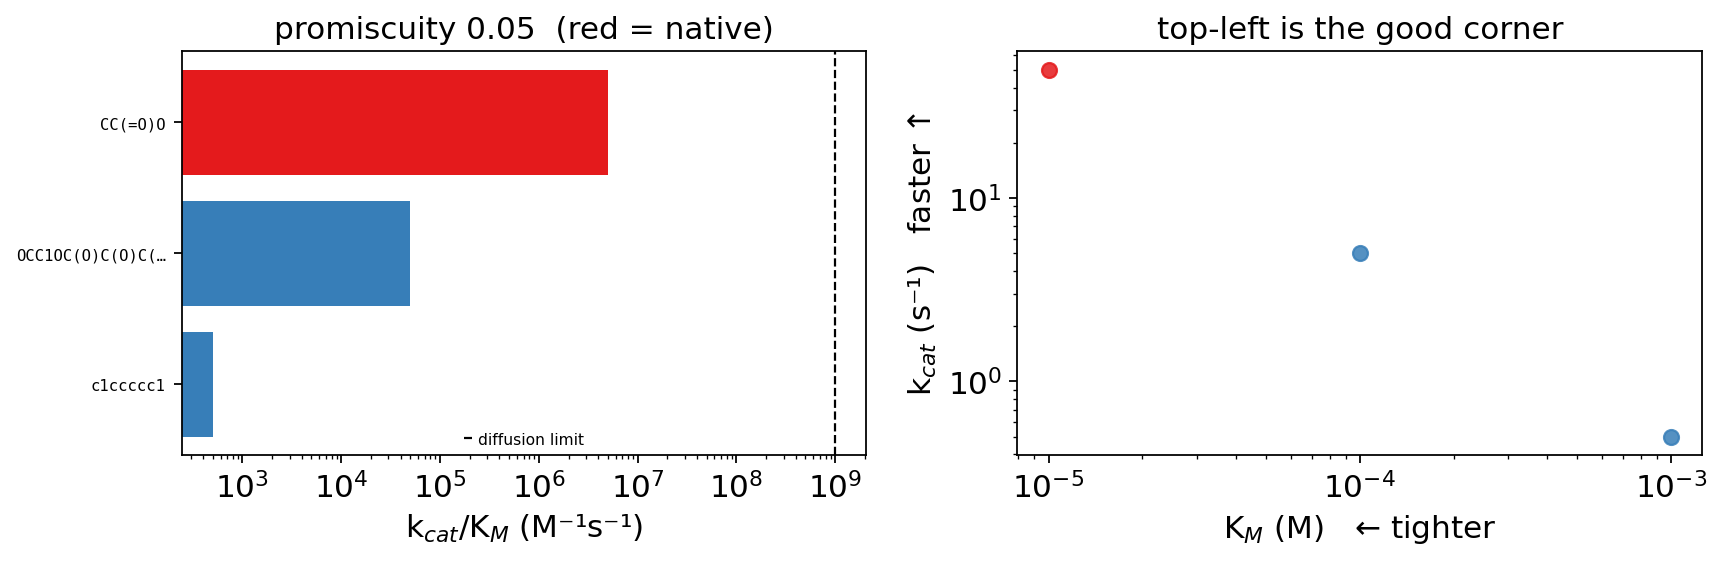

In [11]:
ov.synbio.plot_substrate_scope(scope)


## 6 — Thermostability without a large model

Resurrecting an inferred ancestor is one of the most reliable routes to a more thermostable enzyme, and it long predates deep learning — it needs a sequence family and a tree, not a GPU.

`ov.alignment.msa` works in memory on a dict of sequences, using MAFFT when installed and a built-in progressive aligner otherwise. Here is a real lysozyme C family.


In [12]:
family = ov.synbio.reference_family('lysozyme')
alignment = ov.alignment.msa(family)
tree = ov.alignment.protein_tree(alignment)
print(alignment)
print(tree.newick)


>> /home/users/steorra/miniforge3/bin/mafft --thread 4 --auto /tmp/ov_msa_9unv0zxi/in.faa


>> /home/users/steorra/miniforge3/bin/FastTree -gamma /tmp/ov_tree_q700wkb5/aln.faa


Alignment(4 sequences x 129 columns, method='mafft')
(quail:0.024246280,duck:0.024140518,(chicken:0.032411167,turkey:0.000000006)0.458:0.008181877);


(<Figure size 1440x281.6 with 2 Axes>,
 [<Axes: title={'center': '4 sequences, columns 1-129 (mafft)'}, ylabel='cons.'>,
  <Axes: xlabel='alignment column'>])

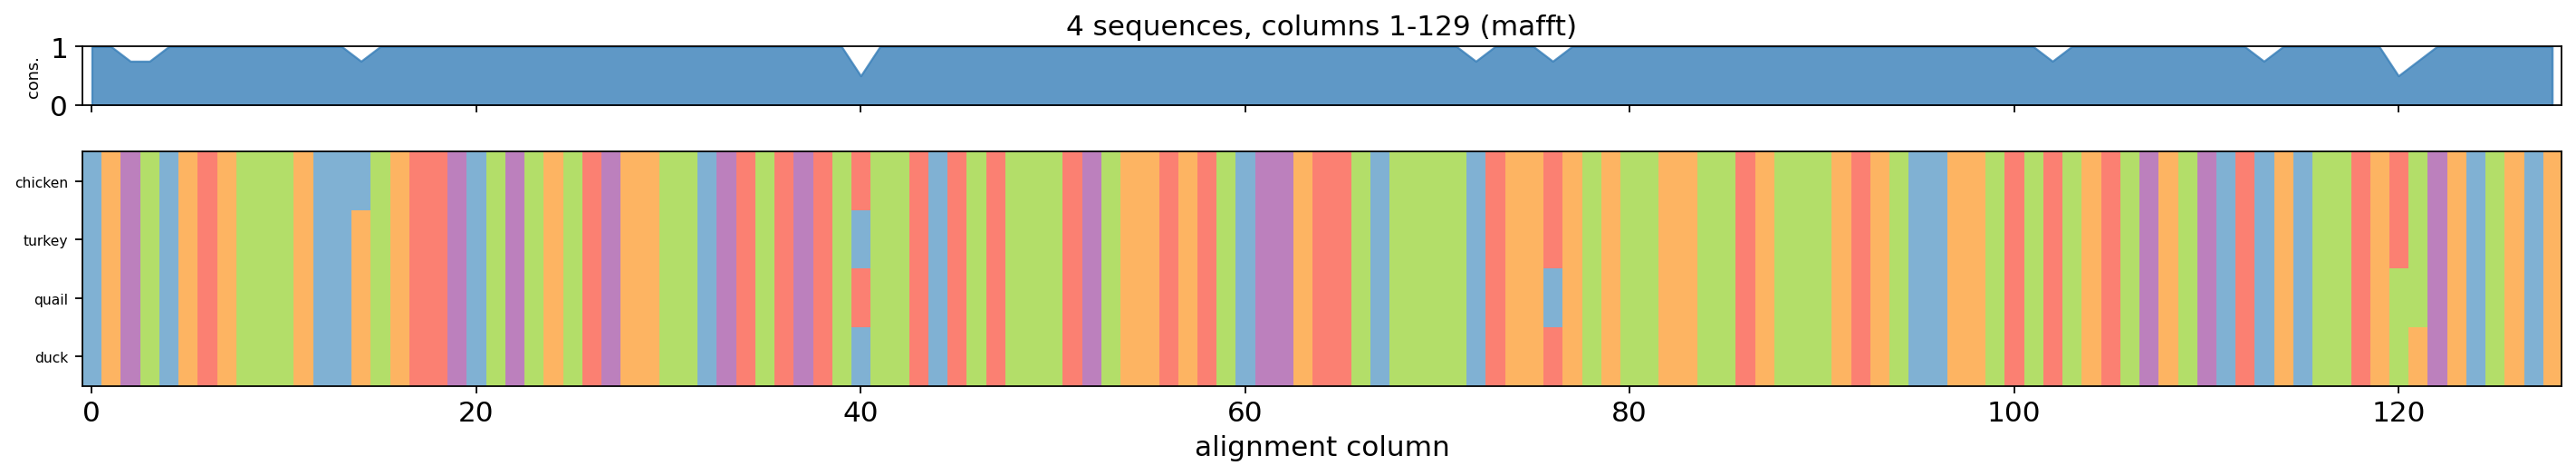

In [13]:
ov.alignment.plot_msa(alignment)


(<Figure size 560x214.4 with 1 Axes>, <Axes: xlabel='substitutions per site'>)

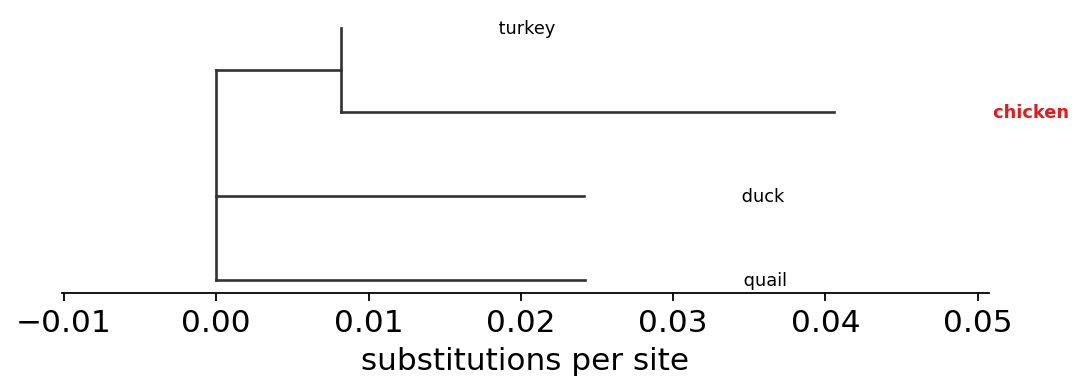

In [14]:
ov.alignment.plot_tree(tree, highlight=['chicken'])


`ancestral_reconstruction` runs a **sequence-weighted column consensus** — `method='weighted_consensus'`, with `'ml'` kept as an alias — and returns a per-site **support** value. It is *not* marginal maximum likelihood: there is no substitution model and no likelihood over branch lengths, and this notebook used to claim otherwise. For real ancestral states use RAxML-NG, IQ-TREE `--ancestral` or PAML on a rooted tree. What this is good for is the same thing either way: Those posteriors are the useful output: the ambiguous sites are the reconstruction's guesses, and ordering the top alternatives at just those positions as a small library is standard practice and cheaper than trusting one sequence.


In [15]:
ancestor = ov.synbio.ancestral_reconstruction(alignment, tree=tree)
print(ancestor)
print('sites worth turning into a library:', ancestor.ambiguous_sites())


AncestralSequence(weighted_consensus, 129 aa, mean posterior 0.933, 10 ambiguous sites)
sites worth turning into a library: [3, 4, 15, 41, 73, 77, 103, 114, 121, 122]


In [16]:
print(ancestor.to_frame().loc[ancestor.ambiguous_sites()[:5]])


          column residue  posterior runner_up  runner_up_posterior
position                                                          
3              3       Y   0.716667         F             0.240476
4              4       G   0.716667         S             0.240476
15            15       L   0.716667         H             0.240476
41            41       H   0.478571         Q             0.478571
73            73       K   0.716667         R             0.240476


The cheaper cousin is the column-wise consensus. It often works, and it can also produce a protein no lineage ever had — so it is worth computing both and looking at where they disagree.


In [17]:
consensus = ov.synbio.consensus_sequence(alignment)
differ = [i + 1 for i, (a, b) in enumerate(zip(consensus, ancestor.sequence)) if a != b]
print('consensus == ancestor:', consensus == ancestor.sequence, '| differing positions:', differ)


consensus == ancestor: True | differing positions: []


(<Figure size 939.2x256 with 1 Axes>,
 <Axes: title={'center': 'weighted_consensus reconstruction from 4 sequences — mean 0.93, 10 sites to library'}, xlabel='ancestral residue position', ylabel='posterior'>)

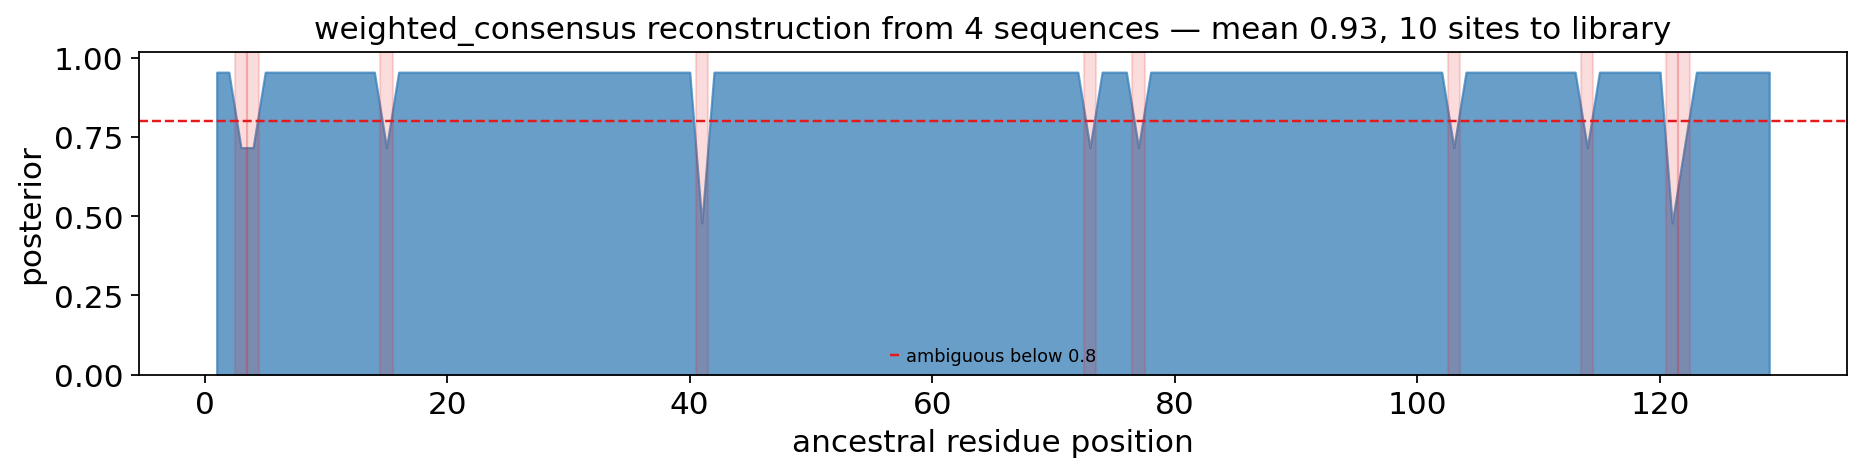

In [18]:
ov.synbio.plot_ancestral_confidence(ancestor)


## 7 — Harmonisation is not optimisation

`codon_optimize` maximises CAI: every codon becomes the host's fastest. For a small, fast-folding protein that is right. For a difficult eukaryotic protein it is often exactly wrong — translation speed is part of the folding programme, and native mRNAs use rare codons at domain boundaries to pause the ribosome while the previous domain folds. Flattening those pauses gives you more protein and less *folded* protein.

`codon_harmonize` preserves the rhythm: each codon's rank within its synonymous family is carried across to the host. Rare stays rare.


In [19]:
GAPDH = ov.synbio.GAPDH_CDS
harmonised = ov.synbio.codon_harmonize(GAPDH, 'h_sapiens', 'e_coli')
print(harmonised)


HarmonizationResult(h_sapiens->e_coli, 38 codons changed, frequency r=0.932, 2 rare codons introduced, CAI in target 0.676 (optimise would give 1.000))


In [20]:
print(ov.synbio.compare_codon_strategies(GAPDH, 'h_sapiens', 'e_coli'))


            cai_in_target        gc  codons_changed
strategy                                           
native           0.648435  0.481481               0
optimized        1.000000  0.506173              31
harmonized       0.675908  0.475309              38


The two strategies pull in opposite directions, and the table shows by how much. If harmonised CAI ever equalled the optimised value, harmonisation would have silently become optimisation.

## 8 — Can it be synthesised at all?

A sequence can be perfectly optimal and still un-orderable. `synthesis_complexity` scores the features that make commercial synthesis fail or cost more, each located so it can be fixed rather than just priced.


In [21]:
tricky = GAPDH + 'A' * 14 + GAPDH
assessment = ov.synbio.synthesis_complexity(tricky)
print(assessment)
for issue in assessment.issues[:4]:
    print(' -', issue)


SynthesisAssessment(likely to be rejected, score=0.85, 5 issues, GC=46.2%)
 - gc_extreme(126-175: GC=32% in a 50-nt window)
 - homopolymer(163-177: 15xA)
 - direct_repeat(177-338: 162 nt repeat of position 143)
 - blocking(1-338: 162 nt perfect direct repeat (>= 100 nt is refused outright, not quoted))


(<Figure size 840x400 with 2 Axes>,
 [<Axes: title={'center': 'likely to be rejected  (score 0.85, 5 issues, 338 nt)'}, ylabel='GC (50-nt window)'>,
  <Axes: xlabel='position (nt)'>])

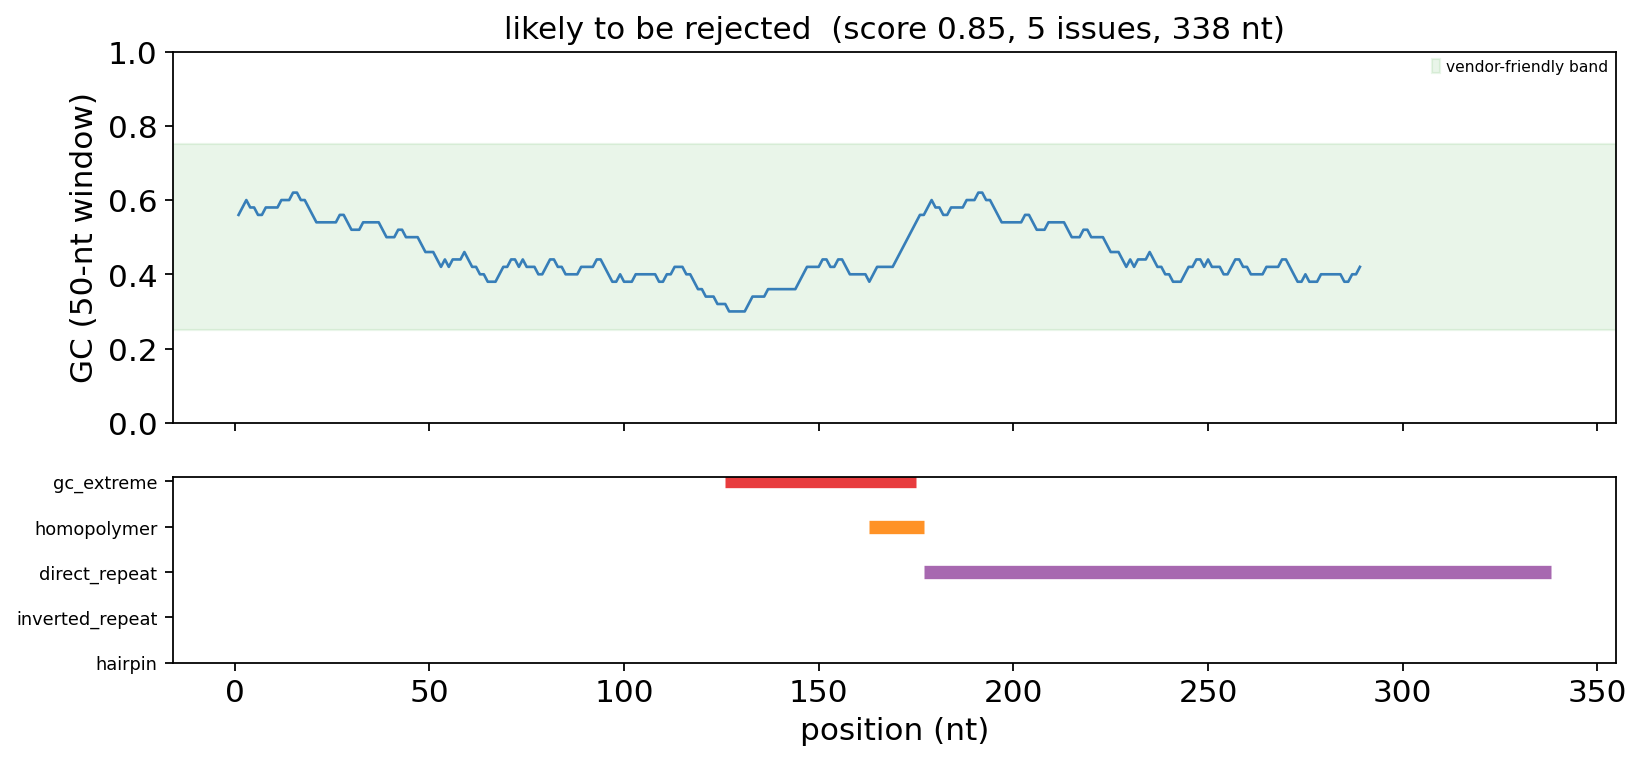

In [22]:
ov.synbio.plot_synthesis_complexity(tricky)


## 9 — Golden Gate junctions that actually work

`golden_gate` orders fragments by complementary overhangs. That answers "is there a valid order" and not "will it assemble". Ligase joins mismatched overhangs too, at a pair-specific rate — below about six fragments the wrong products are rare enough to ignore, above that they compound.


In [23]:
for n in (4, 8, 12, 16, 20):
    overhangs = ov.synbio.design_overhang_set(n)
    report = ov.synbio.overhang_fidelity(overhangs)
    print(f'{n:2d} fragments: fidelity {report.fidelity:.4f}  {report.verdict}')


 4 fragments: fidelity 0.9999  high fidelity
 8 fragments: fidelity 0.9909  high fidelity
12 fragments: fidelity 0.9766  high fidelity
16 fragments: fidelity 0.9023  usable
20 fragments: fidelity 0.6440  expect misassembly


The degradation is real — 1.000 at four overhangs to 0.41 at twenty-four — and it is the phenomenon the function exists to expose. But do not read the absolute numbers as a ceiling on Golden Gate: NEB sells kits validated for one-pot 24-fragment assembly, and published Potapov/Pryor-selected 4-nt sets of 20-30 members reach measured fidelity above 0.9. What the fallback scorer shows is that *this greedy search* on *this invented mismatch model* runs out of room, not that the chemistry does. Hand in measured data via `fidelity_table=` before quoting a number.

Measured NEB ligation data are used when you hand them in via `fidelity_table=`; without one the fallback is labelled `method='mismatch'` and its absolute rates are not NEB's numbers.


In [24]:
good = ov.synbio.overhang_fidelity(['AATG', 'AGGT', 'GCTT', 'CGCT'])
bad = ov.synbio.overhang_fidelity(['AATG', 'AATC', 'GCTT', 'CGCT'])
print('orthogonal set :', good)
print('one mismatch   :', bad, bad.cross_reactions[:1])


orthogonal set : FidelityReport(4 overhangs, fidelity=0.994 [mismatch], high fidelity)
one mismatch   : FidelityReport(4 overhangs, fidelity=0.735 [mismatch], expect misassembly) [AATG/AATC=0.17]


(<Figure size 592x544 with 2 Axes>,
 <Axes: title={'center': 'high fidelity — fidelity 0.991 (mismatch)'}>)

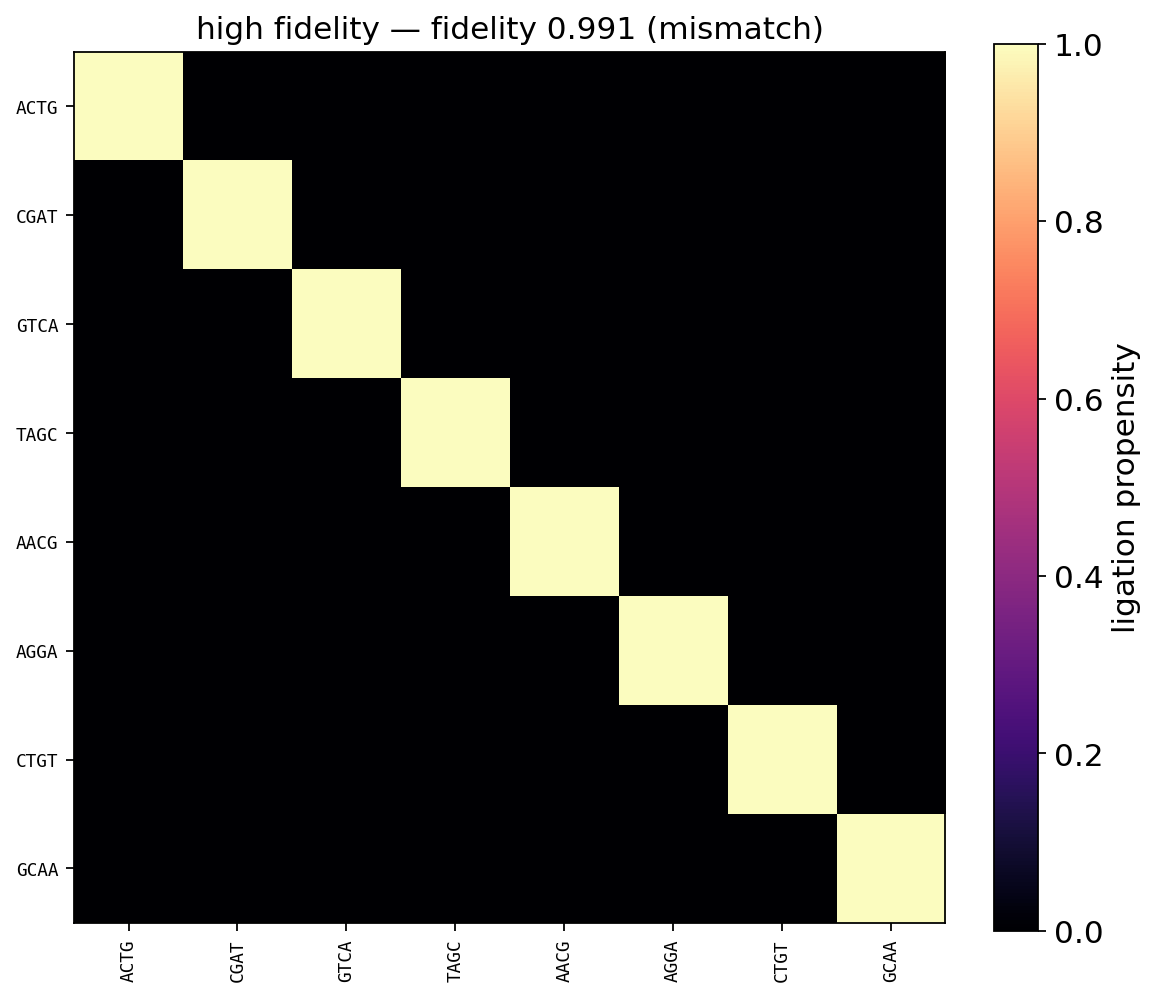

In [25]:
ov.synbio.plot_overhang_fidelity(ov.synbio.overhang_fidelity(ov.synbio.design_overhang_set(8)))


## 10 — The third part of a transcription unit

`promoter_strength` and `rbs_strength` existed; the terminator did not. A weak terminator is transcriptional read-through that silently drives the unit downstream — which looks like a broken promoter and is not.


In [26]:
for name, seq in (('rrnB T1', ov.synbio.RRNB_T1),
                  ('same hairpin, no U-tract', ov.synbio.HAIRPIN_NO_U_TRACT)):
    t = ov.synbio.terminator_strength(seq)
    print(f'{name:26s} {t.strength:.2f}  {t.classification:18s} readthrough {t.readthrough:.0%}')


rrnB T1                    0.92  strong             readthrough 8%
same hairpin, no U-tract   0.25  not a terminator   readthrough 75%


The U-tract is not a bonus term. Without it a hairpin merely *pauses* polymerase — the rU:dA hybrid is what lets the stalled enzyme release — so it gates the score rather than adding to it.

## 11 — Compiling a truth table into DNA

`genetic_circuit` and `logic_gate` build a circuit you have already designed. `compile_circuit` goes the other way, the way Cello does: give it a truth table, and it synthesises a NOR/NOT network, assigns distinct repressor gates, and **checks that each assignment's signal levels actually separate**. That check is what makes it compilation rather than graph rewriting — a network that type-checks can still fail because the upstream gate's ON level lands in the downstream gate's dead zone.


In [27]:
XOR = {(0, 0): 0, (0, 1): 1, (1, 0): 1, (1, 1): 0}
circuit = ov.synbio.compile_circuit(XOR)
print(circuit)
print(circuit.to_frame()[['kind', 'inputs', 'part', 'dynamic_range']])


CompiledCircuit(6 gates, score=424.05, feasible, 864 nt)
     kind inputs       part  dynamic_range
0   INPUT                       125.000000
1   INPUT                       125.000000
2     NOT      B    P5_AmtR      46.470965
3     NOR   A,g1  P8_HlyIIR      25.320983
4     NOT      A    P6_LitR      47.228647
5     NOR   g3,B    P4_QacR     172.264258
6     NOR  g2,g4    P1_PhlF     182.950235
7     NOT     g5    P2_SrpR     424.046436
8  OUTPUT     g6                       inf


(<Figure size 880x304 with 2 Axes>,
 [<Axes: title={'center': 'red = worst OFF, green = worst ON  (output margin 424.0x)'}, xlabel='signal level (RPU, log scale)'>,
  <Axes: title={'center': 'truth table'}, xlabel='A B', ylabel='expected output'>])

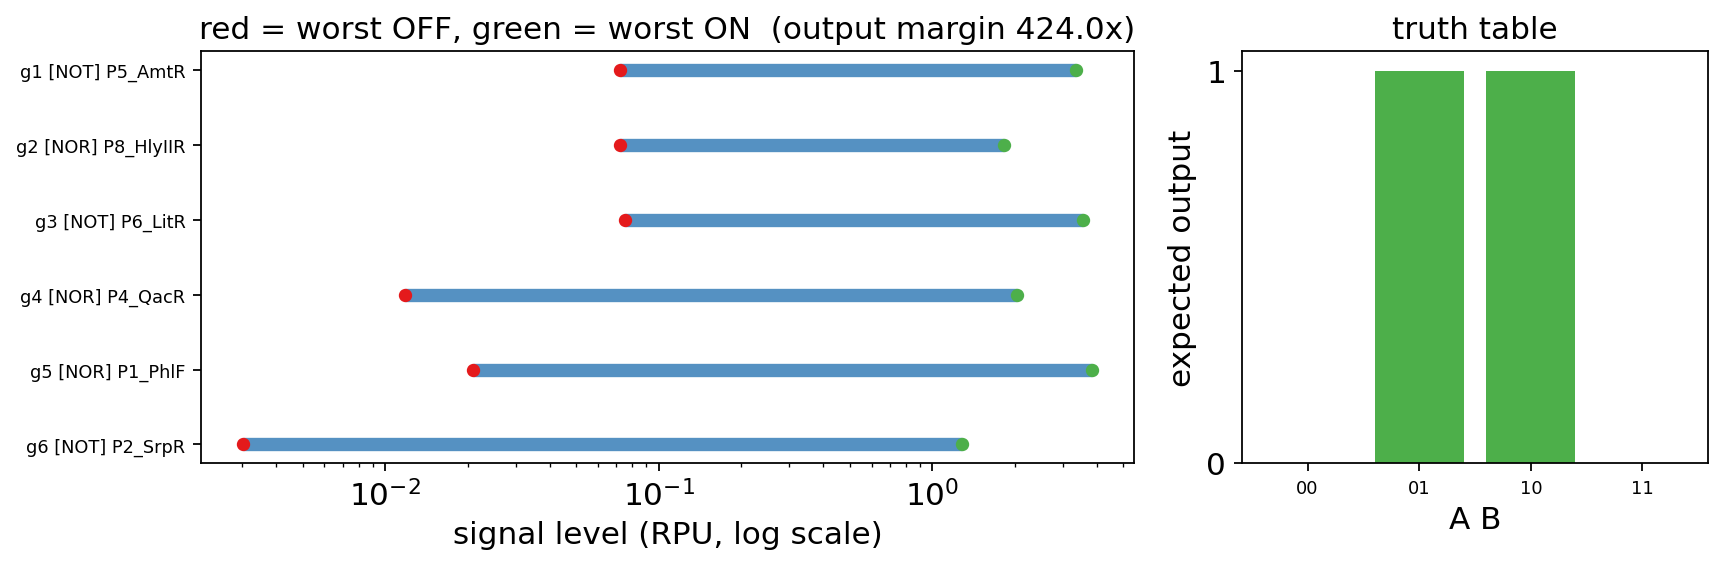

In [28]:
ov.synbio.plot_compiled_circuit(circuit)


Asking for an impossible output margin shows the check working — the topology is still valid, the parts are not.


In [29]:
impossible = ov.synbio.compile_circuit(XOR, min_dynamic_range=1e6)
print('feasible:', impossible.feasible)
print(impossible.failures[0])


feasible: False
库里没有任何一种分配能让输出的 ON/OFF 分离度达到 1000000.0x。拓扑是对的,但电平配不上 —— 上游门的 ON 电平落进了下游门的死区。换更强的门、降低 min_dynamic_range,或改用输入摆幅更大的传感器。


## 12 — Screening before it is ordered

Screening a construct before it is ordered or shared has moved from best practice toward a requirement. This is a screening **harness**: it translates the construct in all six frames, aligns against reference sets *you* configure, and subtracts hits equally well explained by benign housekeeping homology.

It ships **no sequences of concern** — a set bundled inside an analysis package would be both stale and irresponsible — and with no reference configured it **raises rather than returning "clean"**. A pass recorded on an unconfigured screen manufactures false assurance that gets filed and believed.


In [30]:
try:
    ov.synbio.screen_sequence(circuit.dna)
except ValueError as exc:
    print(str(exc).splitlines()[0])


没有配置任何关注序列库,筛查无法进行。


That refusal is the guardrail. Here is the tool itself, pointed at a reference supplied in memory — `databases=` takes a `{identifier: sequence}` mapping as well as FASTA paths, because a reference is not always a file on disk.

**The entry below is an innocuous stand-in** (a GFP sequence playing the part of a reference entry) so that this notebook runs without anyone shipping or downloading sequences of concern. What is being demonstrated is the harness, not the biology of any particular hazard.


In [31]:
reference = {'reference_entry_01': ov.synbio.reference_protein('gfp')}
report = ov.synbio.screen_sequence(harmonised.sequence, databases=reference)
print(report)


ScreeningReport(pass, 0 flagged of 0 hits)


Under the hood the construct is read in all six frames before anything is aligned — `translate_frames` is that step, exposed so the claim is checkable rather than asserted.


In [32]:
frames = ov.synbio.translate_frames('ATGGCTTGTAAACGT')
print({k: v for k, v in frames.items()})


{'+1': 'MACKR', '+2': 'WLVN', '+3': 'GL*T', '-1': 'TFTSH', '-2': 'RLQA', '-3': 'VYKP'}


Now screen something that *does* match the reference, and then the same construct reverse-complemented. Six-frame coverage is what makes the second one still get caught — a screen reading only the annotated strand is evaded by flipping the insert.


In [33]:
insert = ov.synbio.codon_optimize(ov.synbio.reference_protein('gfp'), host='e_coli').sequence
forward = ov.synbio.screen_sequence(insert, databases=reference)
flipped = ov.synbio.screen_sequence(ov.synbio.reverse_complement(insert), databases=reference)
print('forward :', forward.decision, sorted({h.query_frame for h in forward.hits}))
print('flipped :', flipped.decision, sorted({h.query_frame for h in flipped.hits}))


forward : flag ['+1']
flipped : flag ['-1']


In [34]:
print(forward.summary())


decision: FLAG
sequence: dna, 714 units
databases: inline_reference.faa
hits: 1 total, 1 not explained by benign homology
  - +1 1-238 -> reference_entry_01 (100% id, E=5.6e-186)
note: 同源筛查是必要条件而非充分条件:它看不到同源性不携带的功能,继承参考库的所有缺口,也无法判断意图与语境。此结果是人工复核的输入。


(<Figure size 880x304 with 2 Axes>,
 [<Axes: title={'center': 'decision: FLAG  (grey = explained by benign homology)'}, xlabel='position in translated frame'>,
  <Axes: title={'center': 'hit strength'}, xlabel='identity to reference (%)', ylabel='hits'>])

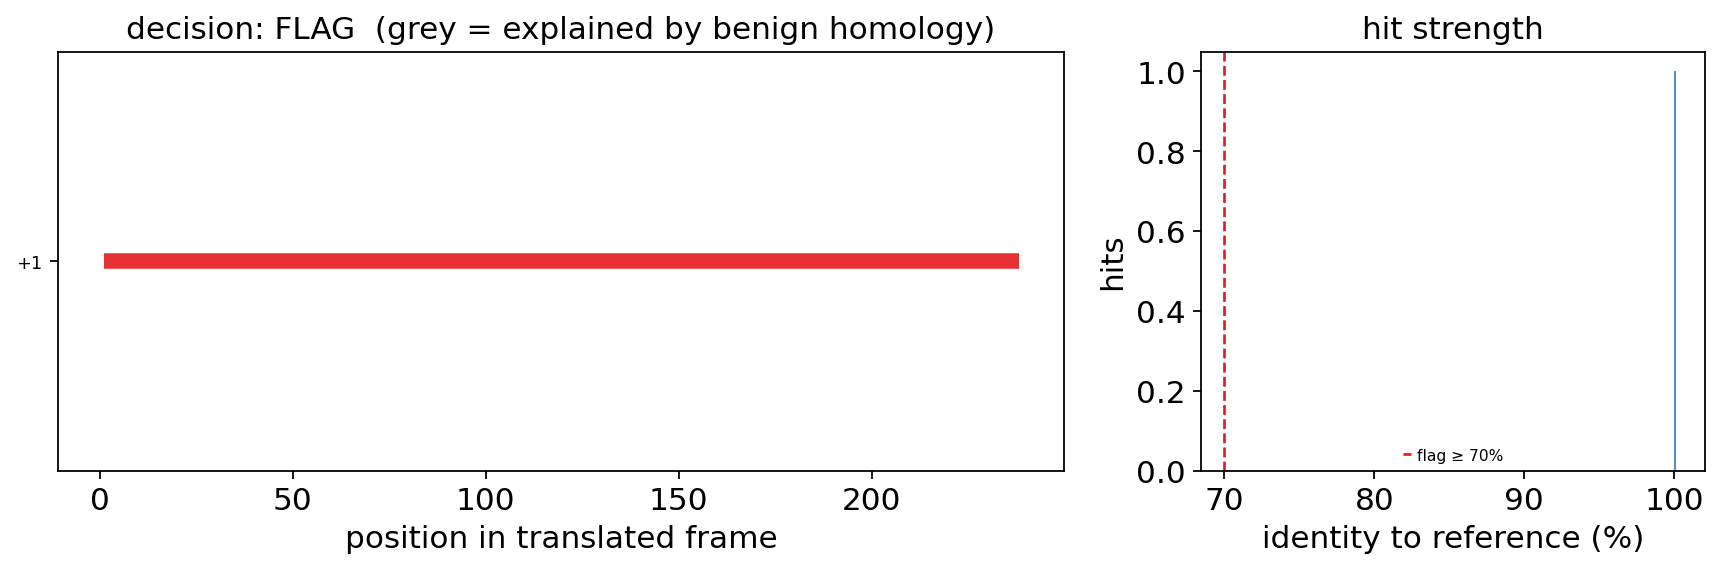

In [35]:
ov.synbio.plot_screening(forward)


Point it at a reference you are entitled to use — your institution's list, the NTI/IBBIS Common Mechanism biorisk database, or a provider's — via `databases=` or `OMICOS_BIOSECURITY_DB`. Six-frame coverage is load-bearing: a screen that reads only the annotated strand is evaded by reverse-complementing the construct.

A homology screen is necessary and not sufficient. It cannot see function that homology does not carry, it inherits every gap in its reference, and it says nothing about intent — the report's `decision` is an input to human review, never a clearance.

## 13 — Choosing something to put it in

`select_backbone` ranks vectors on what actually decides the choice. Wrong host, oversized insert and an incompatible replication origin are **disqualifications**, not low scores: a plasmid that cannot replicate is not a weak option, and sharing an origin is the usual reason a two-plasmid system quietly loses one of them.


In [36]:
choices = ov.synbio.select_backbone(host='e_coli', insert_kb=2.5,
                                    expression=True, secretion=True)
for choice in choices[:3]:
    print(f'{choice.backbone.name:14s} {choice.score:5.2f}  {choice.reasons[:2]}')


pET22b          3.29  ['带表达启动子 T7', '带分泌信号(周质/胞外)']
pCDF-1b         1.79  ['带表达启动子 T7']
pET28a          1.79  ['带表达启动子 T7']


In [37]:
compatible = ov.synbio.select_backbone(host='e_coli', incompatible_with='pBR322')
print('usable alongside a pBR322 plasmid:',
      [c.backbone.name for c in compatible if not c.disqualified][:4])


usable alongside a pBR322 plasmid: ['pTwist-Kan-Ori', 'pACYC184', 'pCDF-1b', 'pSB1C3']


(<Figure size 600x427.2 with 1 Axes>,
 <Axes: title={'center': '8/11 usable (red = disqualified)'}, xlabel='suitability score'>)

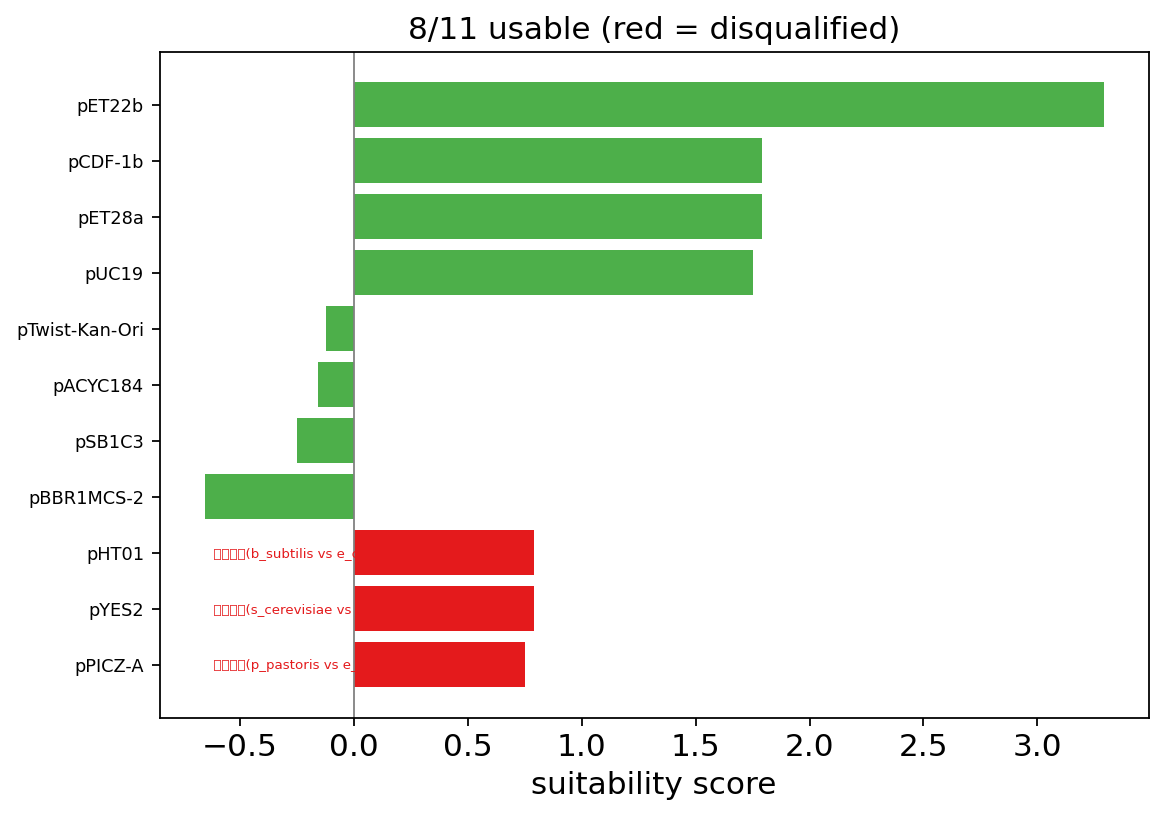

In [38]:
ov.synbio.plot_backbone_choice(choices)


Backbone selection needs no network. Part *search* does, and it is opt-in for a reason — a library function that silently reaches the internet is a problem in a batch job and a worse one behind an institutional proxy.


In [39]:
try:
    ov.synbio.query_parts('T7 promoter')
except ValueError as exc:
    print(str(exc).splitlines()[0])


query_parts 需要联网访问部件库,请显式传 allow_network=True。默认关闭是因为库函数不该在批处理作业里悄悄发起网络请求(在机构代理后面尤其容易卡住)。载体骨架选择 select_backbone 有内置目录,不需要联网。


With `allow_network=True` this queries SynBioHub and the iGEM Registry, and `ov.synbio.fetch_part` retrieves one part with its sequence. Addgene is deliberately not searchable here: it has no public search API, so `registry='addgene'` raises and names the way round it (export GenBank, read it with `ov.synbio.read_genbank`) rather than pretending.

One more bridge worth knowing about: `ov.synbio.enzyme_dynamics` takes a designed sequence through `predict_structure` into `ov.mol.simulate`, so a design can be put under molecular dynamics with a substrate present. It is not run here because it needs a GPU and the OpenMM stack — see the `ov.mol` molecular-dynamics tutorial. QM/MM is **not** implemented anywhere in omicverse; a reaction barrier needs a quantum engine coupled to the MM region, which is a different dependency stack.


## Where this lands

The design that comes out the other end has been checked for solubility, secretion, aggregation, affinity and substrate scope; its DNA has been harmonised rather than blindly optimised, scored for synthesisability, given orthogonal assembly junctions and a real terminator; and it has been screened and placed in a compatible vector.

None of the sequence-level predictors here is a calibrated model, and each says so through its `method` field — they are transparent arithmetic with hooks to Protein-Sol, SignalP, DeepLoc, AGGRESCAN, TANGO and UniKP for when a number rather than an ordering is needed.
